# scMultiSim Simulating Multimodal Single-cell Datasets for GRN Infer Benchmark

- Explore different param settings
- Run Simulation for GRN Infer benchmark

In [11]:
library(scMultiSim)
library(dplyr, quietly = T)
library(slingshot, quietly = T)
library(uwot, quietly = T)
library(mclust, quietly = T)


Attaching package: ‘dplyr’


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

    collapse, desc, intersect, setdiff, slice, union


The following objects are masked from ‘package:S4Vectors’:

    first, intersect, rename, setdiff, setequal, union


The following objects are masked from ‘package:BiocGenerics’:

    combine, intersect, setdiff, union


The following object is masked from ‘package:matrixStats’:

    count


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [12]:
scmultisim_help("options")

scMultiSim  v1.2.0

[GENERAL]

rand.seed  (default: 0)
	scMultiSim should produce the same result if all other parameters are th
	e same.
	The value should be a numeric.
threads  (default: 1)
	Set to larger than 1 to use multithreading for some part of the simulati
	on.
	The value should be an integer between 1 and 4096.
speed.up  (default: FALSE)
	Use experimental speed and memory optimization.
	The value should be a logical.

[GENE]

GRN  (default: NULL)
	The GRN network.
	It should be a data frame with 3 columns (target, regulator, effect). Su
	pply NA to disable the GRN effect.
grn.effect  (default: 1)
	Overall strength of the GRN effect on the expression. Different from the
	 effect column in the GRN data frame, which is the relative effect of ea
	ch TF-target pair.
	The value should be a numeric between 0 and Inf.
num.genes  (default: NULL)
	Number of genes if GRN is disabled.
	The value should be an integer between 1 and Inf.
unregulated.gene.ratio  (default: 0.1)
	Ratio of unre

NULL

In [3]:
data(GRN_params_100)
head(GRN_params_100)
dim(GRN_params_100)

,regulated.gene,regulator.gene,regulator.effect
,<int>,<int>,<dbl>
1,16,10,1.768699
2,29,10,1.675360
3,62,10,3.723509
4,55,10,2.866182
5,81,80,4.020744
6,73,80,2.353371


[1] 130   3

In [4]:
data(GRN_params_1139)
head(GRN_params_1139)
dim(GRN_params_1139)

,regulated.gene,regulator.gene,regulator.effect
,<int>,<int>,<dbl>
1,1,686,4.057811
2,1,805,2.312057
3,3,686,4.469269
4,3,805,2.267506
5,4,686,2.231499
6,4,1006,3.985946


[1] 1432    3

## Test the Function

In [30]:
options <- list(
  rand.seed = 0,
  GRN = GRN_params_100,
  num.cells = 1000,
  num.genes = 500,
  num.cifs = 50,
  cif.sigma = 0.5,
  tree = Phyla5(),
  diff.cif.fraction = 0.8,
  do.velocity = TRUE
)

In [31]:
results <- sim_true_counts(options)

Time spent: 1.97 mins


In [32]:
names(results)

[1] ".grn"             "unspliced_counts" ".options"         ".n"              
 [5] "region_to_gene"   "atacseq_data"     "giv"              "kinetic_params"  
 [9] "num_genes"        "velocity"         "cif"              "hge_scale"       
[13] "counts"           "cell_meta"        "atac_counts"      "region_to_tf"    
[17] "grn_params"       "cell_time"

In [33]:
str(results)

<environment: 0x2f7ea5a8> 
 - attr(*, "name")= chr "scMultiSim Result"


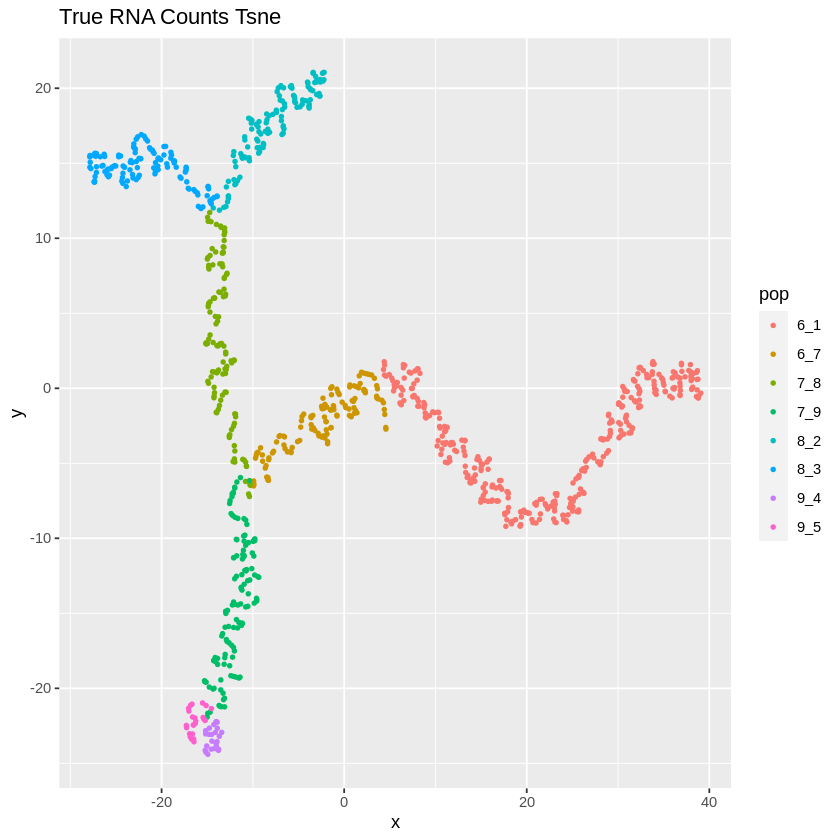

In [34]:
plot_tsne(log2(results$counts + 1),
         results$cell_meta$pop,
         legend = 'pop', plot.name = 'True RNA Counts Tsne')

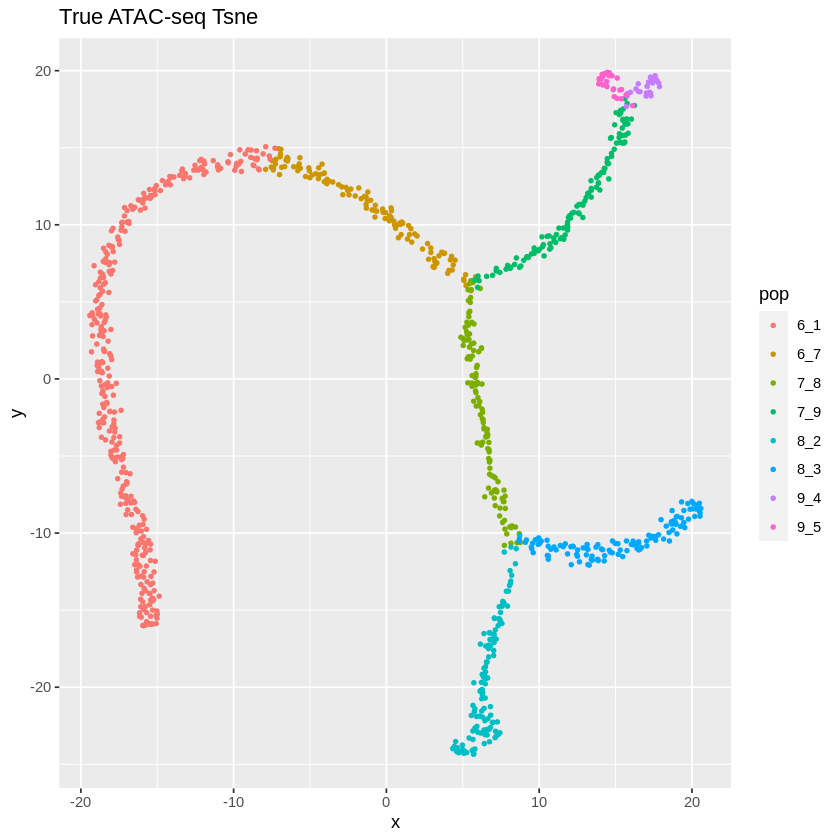

In [35]:
plot_tsne(log2(results$atacseq_data + 1),
         results$cell_meta$pop,
         legend = 'pop', plot.name = 'True ATAC-seq Tsne')

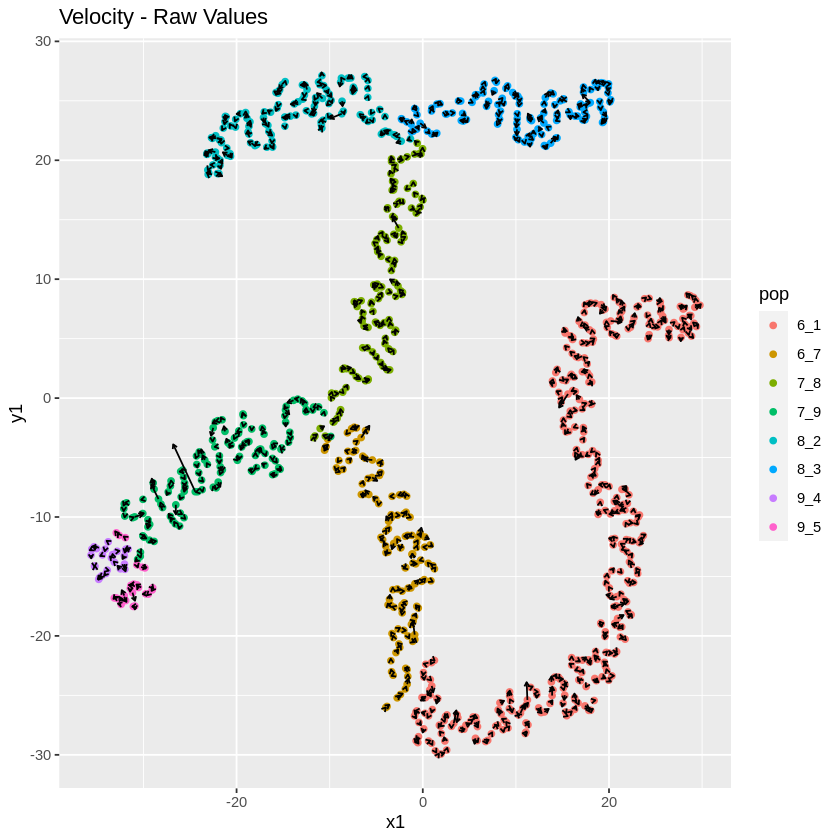

$raw

$normalized

$knn_normalized


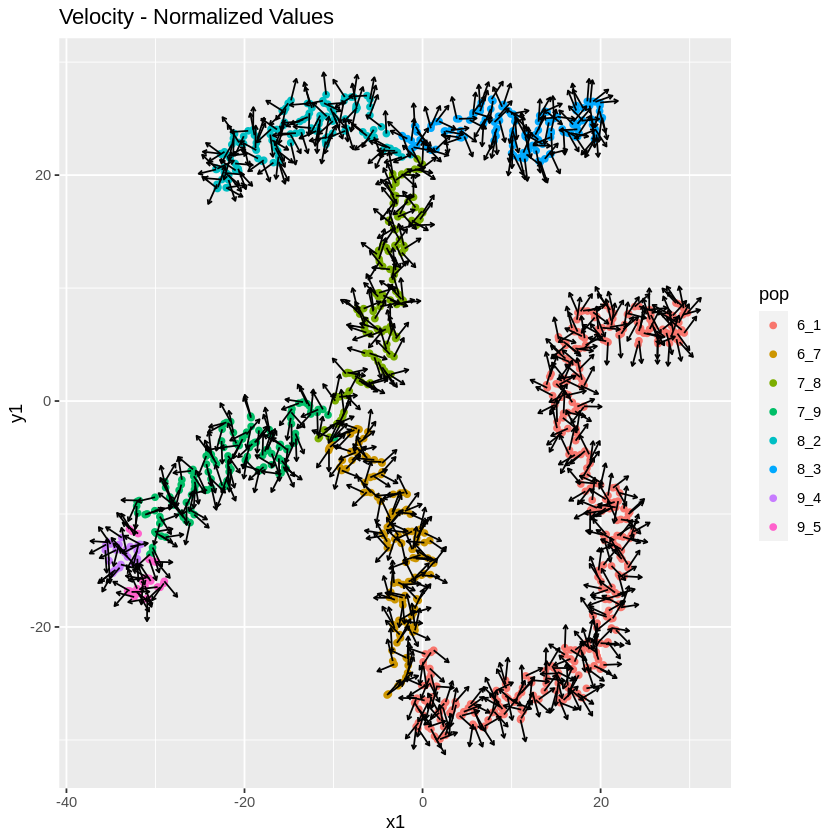

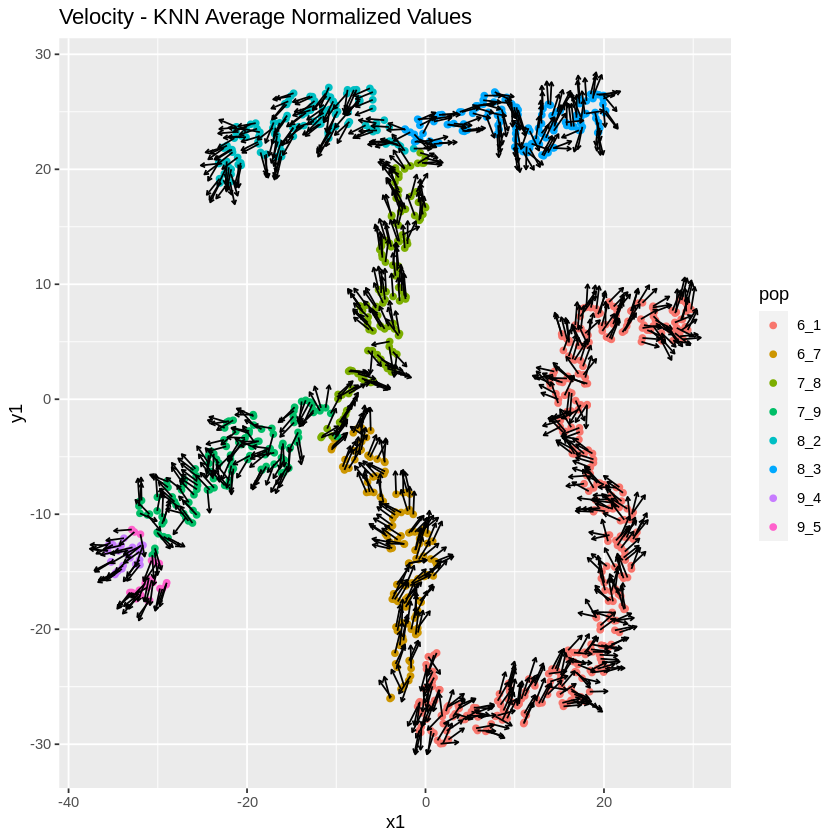

In [36]:
plot_rna_velocity(results, arrow.length = 2)

NULL

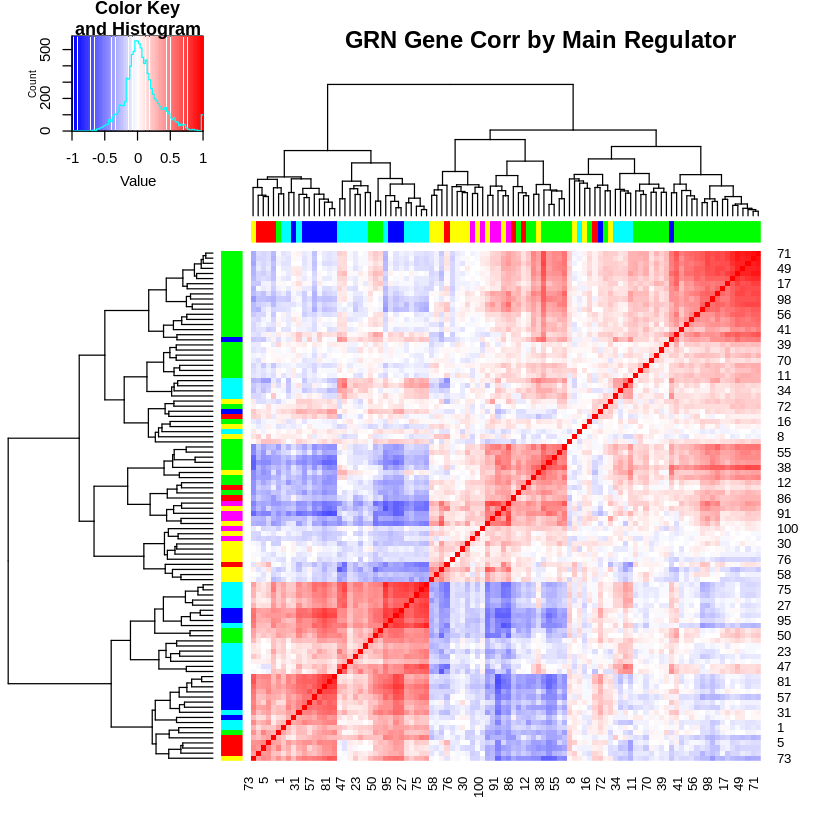

In [37]:
plot_gene_module_cor_heatmap(results)

## Running Simulation for GRN Benchmark

In [14]:
.output_grn_res <- function(res, root, noise = F) {
  dir.create(root, recursive = T)
  
  counts <- if (noise) {
    log2(res$counts_obs + 1)
  } else {
    log2(res$counts + 1)
  }
  
  rownames(counts) <- paste0("gene", 1:res$.n$gene)
  colnames(counts) <- paste0("cell", 1:res$.n$cell)
  write.csv(counts, file = file.path(root, "ExpressionData.csv"), quote = F)
  
  ## Don't use this part(Slingshot pseudotime), use dpt instead 
  # sce <- SingleCellExperiment(assays = List(counts = counts))
  # FQnorm <- function(counts){
  #   rk <- apply(counts,2,rank,ties.method='min')
  #   counts.sort <- apply(counts,2,sort)
  #   refdist <- apply(counts.sort,1,median)
  #   norm <- apply(rk,2,function(r){ refdist[r] })
  #   rownames(norm) <- rownames(counts)
  #   return(norm)
  # }
  # assays(sce)$norm <- FQnorm(assays(sce)$counts)
  
  # pca <- prcomp(t(log1p(assays(sce)$norm)), scale. = FALSE)
  # rd1 <- pca$x[,1:2]
  
  # rd2 <- uwot::umap(t(log1p(assays(sce)$norm)))
  # colnames(rd2) <- c('UMAP1', 'UMAP2')
  # reducedDims(sce) <- SimpleList(PCA = rd1, UMAP = rd2)
  
  # cl1 <- Mclust(rd2)$classification
  # colData(sce)$GMM <- cl1
  
  # cl2 <- kmeans(rd2, centers = 4)$cluster
  # colData(sce)$kmeans <- cl2
  
  # sce <- slingshot(sce, clusterLabels = 'GMM', reducedDim = 'UMAP')
  
  # time <- list()
  # i = 1
  # while (T) {
  #   k <- sprintf("slingPseudotime_%d", i)
  #   if (is.null(sce[[k]])) {
  #     break
  #   } else {
  #     time[[sprintf("Pseudotime_%d", i)]] <- sce[[k]]
  #   }
  #   i <- i + 1
  # }
  
  # time <- as.data.frame(time)
  # rownames(time) <- colnames(res$counts)
  # write.csv(time, file = file.path(root, "PseudoTime.csv"), quote = F)
  
  gp <- res$.grn$params
  grn <- data.frame(
    Gene1 = paste0("gene", gp[,2]),
    Gene2 = paste0("gene", gp[,1]),
    Type = ifelse(gp[,3] > 0, "+", "-"))
  write.csv(grn, file = file.path(root, "refNetwork.csv"), quote = F, row.names = F)
  
  saveRDS(res, file.path(root, "res.rds"))
}

### grn100_tree1_1000_cells110_genes_sigma0.1

In [15]:
library(doParallel)
registerDoParallel(cores = 8)

(function() {
  foreach (seed = 1:8) %dopar% {
    options_ <- list(
      rand.seed = seed,
      threads = 1,
      GRN = GRN_params_100,
      num.cells = 1000,
      num.cifs = 50,
      tree = Phyla1(),
      intrinsic.noise = 1,
      diff.cif.fraction = 0.2,
      debug = F
    )

    results <- sim_true_counts(options_)

    .output_grn_res(results, paste0("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_tree1_1000_cells110_genes_sigma0.1_", as.character(seed)), F)
    gc()
  }
})()

(function() {
  foreach (seed = 1:8) %dopar% {
    options_ <- list(
      rand.seed = seed,
      threads = 1,
      GRN = GRN_params_100,
      num.cells = 1000,
      num.cifs = 50,
      tree = Phyla1(),
      intrinsic.noise = 1,
      diff.cif.fraction = 0.2,
      debug = F
    )

    results <- sim_true_counts(options_)
    add_expr_noise(results)
    divide_batches(results)

    .output_grn_res(results, paste0("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_noise_tree1_1000_cells110_genes_sigma0.1_", as.character(seed)), T)
    gc()
  }
})()

Loading required package: foreach

Loading required package: iterators

Loading required package: parallel



,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7041371,376.1,12598254,672.9,10369446,553.8
Vcells,14551561,111.1,23715153,181.0,23715153,181.0
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7041468,376.1,12598254,672.9,10369446,553.8
Vcells,14551788,111.1,23714284,181.0,23714284,181.0
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7041475,376.1,12598254,672.9,10369446,553.8
Vcells,14551798,111.1,23714274,181.0,23714274,181.0
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7041482,376.1,12598254,672.9,10369446,553.8


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057211,376.9,12598254,672.9,10369446,553.8
Vcells,19524261,149.0,34324558,261.9,34324556,261.9
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057218,376.9,12598254,672.9,10369446,553.8
Vcells,19524271,149.0,34346956,262.1,34346956,262.1
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057225,376.9,12598254,672.9,10369446,553.8
Vcells,19524281,149.0,34336853,262.0,34336853,262.0
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057232,376.9,12598254,672.9,10369446,553.8


### grn100_tree1_1000_cells500_genes_sigma0.1

In [16]:
(function() {
  foreach (seed = 1:8) %dopar% {
    options_ <- list(
      rand.seed = seed,
      threads = 1,
      GRN = GRN_params_100,
      num.genes = 500,
      num.cells = 1000,
      num.cifs = 50,
      tree = Phyla1(),
      intrinsic.noise = 1,
      diff.cif.fraction = 0.2,
      debug = F
    )

    results <- sim_true_counts(options_)

    .output_grn_res(results, paste0("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_tree1_1000_cells500_genes_sigma0.1_", as.character(seed)), F)
    gc()
  }
})()

(function() {
  foreach (seed = 1:8) %dopar% {
    options_ <- list(
      rand.seed = seed,
      threads = 1,
      GRN = GRN_params_100,
      num.genes = 500,
      num.cells = 1000,
      num.cifs = 50,
      tree = Phyla1(),
      intrinsic.noise = 1,
      diff.cif.fraction = 0.2,
      debug = F
    )

    results <- sim_true_counts(options_)
    add_expr_noise(results)
    divide_batches(results)

    .output_grn_res(results, paste0("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn100_noise_tree1_1000_cells500_genes_sigma0.1_", as.character(seed)), T)
    gc()
  }
})()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7045742,376.3,12598254,672.9,10661995,569.5
Vcells,21646154,165.2,37050071,282.7,30808393,235.1
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7045749,376.3,12598254,672.9,10662173,569.5
Vcells,21646164,165.2,37050070,282.7,30808392,235.1
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7045756,376.3,12598254,672.9,10662351,569.5
Vcells,21646174,165.2,37567956,286.7,31239964,238.4
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7045763,376.3,12598254,672.9,10662529,569.5


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057487,377.0,12598254,672.9,10957481,585.2
Vcells,29730229,226.9,53538063,408.5,44548386,339.9
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057494,377.0,12598254,672.9,10957659,585.3
Vcells,29730239,226.9,53528494,408.4,44540412,339.9
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057501,377.0,12598254,672.9,10957837,585.3
Vcells,29730249,226.9,53533978,408.5,44544982,339.9
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7057508,377.0,12598254,672.9,10958015,585.3


### grn1139_tree1_1000_cells1139_genes_sigma0.1

In [17]:
library(doParallel)
registerDoParallel(cores = 8)

(function() {
  foreach (seed = 1:8) %dopar% {
    options_ <- list(
      rand.seed = seed,
      threads = 1,
      GRN = GRN_params_1139,
      num.cells = 1000,
      num.cifs = 50,
      tree = Phyla1(),
      intrinsic.noise = 1,
      diff.cif.fraction = 0.2,
      debug = F
    )

    results <- sim_true_counts(options_)

    .output_grn_res(results, paste0("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn1139_tree1_1000_cells1139_genes_sigma0.1_", as.character(seed)), F)
    gc()
  }
})()

(function() {
  foreach (seed = 1:8) %dopar% {
    options_ <- list(
      rand.seed = seed,
      threads = 1,
      GRN = GRN_params_1139,
      num.cells = 1000,
      num.cifs = 50,
      tree = Phyla1(),
      intrinsic.noise = 1,
      diff.cif.fraction = 0.2,
      debug = F
    )

    results <- sim_true_counts(options_)
    add_expr_noise(results)
    divide_batches(results)

    .output_grn_res(results, paste0("/home/chenxufeng/picb_cxf/Data/scMultiSim/bench_grn/datasets/grn1139_noise_tree1_1000_cells1139_genes_sigma0.1_", as.character(seed)), T)
    gc()
  }
})()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7047212,376.4,12598254,672.9,11998155,640.8
Vcells,37850801,288.8,60515808,461.7,60515808,461.7
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7047219,376.4,12598254,672.9,11998181,640.8
Vcells,37850811,288.8,60518146,461.8,60518146,461.8
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7047226,376.4,12598254,672.9,11998188,640.8
Vcells,37850821,288.8,60517244,461.8,60517244,461.8
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7047233,376.4,12598254,672.9,11998195,640.8


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7058275,377.0,12598254,672.9,12038232,643.0
Vcells,51934378,396.3,87321011,666.3,87321011,666.3
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7058282,377.0,12598254,672.9,12038239,643.0
Vcells,51934388,396.3,87322024,666.3,87322023,666.3
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7058289,377.0,12598254,672.9,12038246,643.0
Vcells,51934398,396.3,87398388,666.8,87398385,666.8
,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,7058296,377.0,12598254,672.9,12038272,643.0
